In [1]:
import pandas as pd 

# Load the data.
df = pd.read_csv('company.csv')
# Checking Info.
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [2]:
# For watch the all columns.
pd.set_option('display.width',1000)
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity  ... DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod MonthlyCharges  TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No  ...               No          No          No              No  Month-to-month              Yes           Electronic check          29.85         29.85    No
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes  ...              Yes          No          No              No        One year               No               Mailed check          56.95        1889.5    No
2  3668-QPYBK    Male              0      No         No       2          Yes                No             DSL            Yes  ...               No    

In [3]:
# Checking Missing values.
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
# For converting text into number.
from sklearn.preprocessing import LabelEncoder
#Because Customer id is not used so -
df = df.drop('customerID',axis=1,errors='ignore')

# Apply LableEncoder 
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print(df.head())        

   gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges Churn
0  Female              0     Yes         No       1           No  No phone service             DSL             No          Yes               No          No          No              No  Month-to-month              Yes           Electronic check           29.85        29.85    No
1    Male              0      No         No      34          Yes                No             DSL            Yes           No              Yes          No          No              No        One year               No               Mailed check           56.95       1889.5    No
2    Male              0      No         No       2          Yes                No             DSL            Yes          Yes               No          No        

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score

# Convert the all text data of columns into numeric values.
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category').cat.codes

# X - Independent feature ,, y - Target columns 

X = df.drop("Churn",axis=1)
y = df["Churn"]

# Devide the data for training and testing (80% train , 20% is test)

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Random Forest Classifer 

model = RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)

# Prediction 

y_pred = model.predict(X_test)

# Checking Accuracy 

print("Model Accuracy : ",accuracy_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("Recall Value : ",recall_score(y_test,y_pred))

# Detailed Report 

print("\n              --- Detailed Classification Report --- ")
print(classification_report(y_test,y_pred))

# 0 - No Churn
# 1 - Churn

C:\Users\Asus\AppData\Local\Temp\ipykernel_15100\3126063632.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


Model Accuracy :  0.7984386089425124
Precision :  0.663003663003663
Recall Value :  0.48525469168900803

              --- Detailed Classification Report --- 
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.49      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [6]:
import numpy as np 

# Create a function for predict the data.
def predict_customer_churn(simple_data):
    prediction = model.predict([simple_data]) # Simple data should be a array which is match by another columns.
    probability = model.predict_proba([simple_data])

    if prediction[0] == 1:
        print(f"Warning : This customer may Churn ! ")
        print(f"Confidence score : {probability[0][1]*100:.2f}%")
    else : 
        print(f"Safe : This Customer is stay with Company.") 
        print(f"COnfidence score : {probability[0][1]*100:.2f}%")   

# For Testing take the first row of X_test 
simple_input = X_test.iloc[0].values
print("Input Data : ",simple_input)
predict_customer_churn(simple_input)

Input Data :  [0.000e+00 0.000e+00 1.000e+00 0.000e+00 1.000e+00 0.000e+00 1.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 1.000e+00 2.000e+00 2.480e+01 2.044e+03]
Confidence score : 73.00%


c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


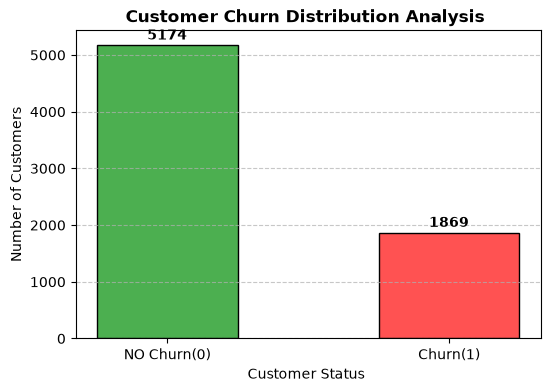

In [7]:
import matplotlib.pyplot as plt

# For watching the churn in counting graph of column.

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,4))
colors = ['#4CAF50','#FF5252']
plt.bar(['NO Churn(0)','Churn(1)'],churn_counts,color=colors,edgecolor='black',width=0.5)

plt.title('Customer Churn Distribution Analysis ', fontsize = 12 , fontweight='bold')
plt.xlabel('Customer Status ',fontsize = 10)
plt.ylabel('Number of Customers',fontsize=10)
plt.grid(axis='y',linestyle='--',alpha=0.7)


# Print the value in bar 

for i, count in enumerate(churn_counts):
    plt.text(i,count + 100,str(count),ha = 'center',fontweight='bold')

plt.show()    

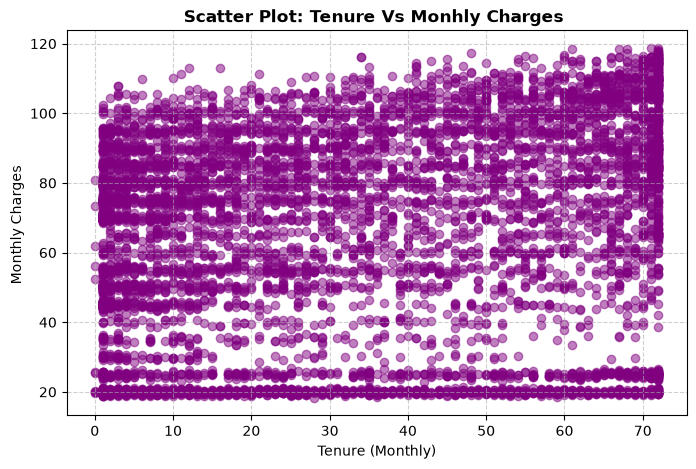

In [11]:
import matplotlib.pyplot as plt

# Scatter plot of Tenure ( Tenure Vs Monthly Charges )

plt.figure(figsize=(8,5))
plt.scatter(df['tenure'],df['MonthlyCharges'],color='purple',alpha=0.5)
plt.title("Scatter Plot: Tenure Vs Monhly Charges ",fontsize=12,fontweight='bold')
plt.xlabel('Tenure (Monthly)',fontsize=10)
plt.ylabel('Monthly Charges ',fontsize=10)
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

In [12]:
# The scatter plot shows how long a customer has been associated with the company(tenure) and how much they pay every month (MonthlyCharges).

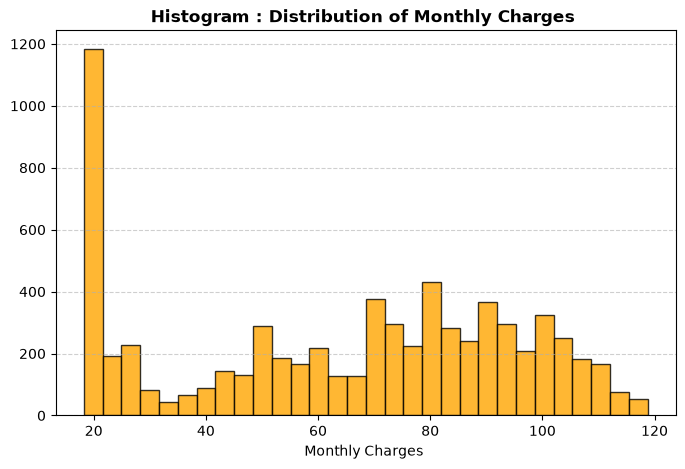

In [15]:
# Histogram of Monthly Charges.
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['MonthlyCharges'],bins=30,color='orange',edgecolor='black',alpha=0.8)
plt.title('Histogram : Distribution of Monthly Charges ', fontsize=12,fontweight='bold')
plt.xlabel('Monthly Charges ',fontsize=10)
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.show()

In [16]:
# A Histogram shows the distribution of customers monthly charges.It helps us see which monthly charge range has the highest number of customers.

In [22]:
# Interactive input function for take and predict the new customer data.
def live_customer_prediction():
    print("--- Customer Churn LIve Predictor ---")
    # For testing we take a random customer from X_test.
    sample_idx  = int(input(f"from 0 {len(X_test)-1} to last row number :"))
    user_input = X_test.iloc[sample_idx].values

# Prediction 

    prediction = model.predict([user_input])    
    probability = model.predict_proba([user_input])
    print("\n [Result]") 
    if prediction[0] == 1:
        print(f"Warning : This Customer leave the Churn")
        print(f"Chances of Churn: {probability[0][1]*100:.2f}%")
    else:
        print(f"Safe: This Customer is stay")    
        print(f"Chances for Stay : {probability[0][0]*100:.2f}%")

# Calling the Function :
live_customer_prediction()        

--- Customer Churn LIve Predictor ---

 [Result]
Chances of Churn: 61.00%


c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [21]:
import numpy as np 
# find churn indices 

churn_indices = np.where(y_test == 1 )[0]
print("The customer which is already churn ")
print(churn_indices[ :1000]) 

The customer which is already churn 
[   0    3    5    8    9   13   15   16   17   19   25   26   37   39
   40   42   44   46   47   48   49   64   70   72   73   81   83   85
   86   87   98  101  105  110  123  126  127  129  131  132  133  136
  139  140  142  157  165  166  171  178  180  186  187  188  190  196
  205  208  214  228  232  234  236  242  247  250  255  261  269  271
  272  273  284  285  286  287  295  297  299  309  313  315  318  326
  332  333  343  344  351  353  356  358  359  365  366  367  368  369
  372  374  378  379  380  385  386  388  393  396  399  400  401  402
  405  408  409  416  417  418  424  425  428  431  435  438  441  442
  445  447  453  458  459  465  467  470  474  477  479  480  482  484
  496  506  507  513  517  518  519  526  535  536  539  545  555  560
  564  569  581  588  589  592  598  603  604  605  610  611  616  617
  620  627  631  632  636  637  638  645  648  649  650  655  656  664
  665  667  674  678  680  681  682  683